# Quickstart: integrate paired RNA + ATAC

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/quickstart.ipynb)

This notebook trains UniVI on 10x Multiome PBMCs (9,631 cells with RNA and ATAC measured in the same cells) and covers the workflow you will reuse for any paired dataset:

1. load paired modalities as AnnData objects
2. split cells, then fit preprocessing on the training cells only
3. configure and train the model
4. embed each modality into the shared latent space
5. check the integration with a UMAP and paired-cell metrics
6. predict gene expression from chromatin accessibility
7. save the trained model and its preprocessing as a reusable reference

The dataset (about 205 MB) is downloaded from [Zenodo](https://doi.org/10.5281/zenodo.19581816) on first use and cached. A GPU makes training take minutes; a CPU works but is slower.

In [1]:
import sys

if "google.colab" in sys.modules:  # install UniVI when running on Colab
    %pip install -q "univi[tutorials]>=1.0"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import cross_modal_predict, encode_adata, evaluate_alignment, pearson_corr_per_feature
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import load_reference, make_loader, save_reference, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.0.0 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training settings live in one cell so you can shorten a first run.

In [3]:
N_EPOCHS = 400       # upper bound; early stopping usually ends sooner
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101          # LSI components fit before dropping the first one

## 1. Load paired data

UniVI takes one AnnData per modality. Paired modalities must describe the same cells in the same order, which `univi.datasets` guarantees for its datasets. Raw counts are in `.X` and in `.layers["counts"]`; cell-type labels are in `obs["cell_type"]`.

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
assert rna.obs_names.equals(atac.obs_names)
print(rna, atac, sep="\n\n")

10x-Multiome-Pbmc10k-RNA.h5ad:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   2%|▏         | 1.05M/50.7M [00:02<01:34, 524kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   4%|▍         | 2.10M/50.7M [00:03<01:18, 619kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   6%|▌         | 3.15M/50.7M [00:04<01:08, 690kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   8%|▊         | 4.19M/50.7M [00:06<01:06, 699kB/s]

...

10x-Multiome-Pbmc10k-ATAC.h5ad:  99%|█████████▉| 152M/154M [02:02<00:00, 1.96MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad:  99%|█████████▉| 153M/154M [02:03<00:00, 2.00MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad: 100%|██████████| 154M/154M [02:03<00:00, 2.07MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad: 100%|██████████| 154M/154M [02:03<00:00, 1.25MB/s]

AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_type', 'gene_name', 'hgnc_id', 'havana_gene', 'tag', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    layers: None (.X), 'counts'

AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type'
  

## 2. Split, then fit preprocessing on training cells

Hold out cells before fitting anything that learns from data (HVG selection, scaling, TF-IDF/LSI). The fitted preprocessors are then applied unchanged to validation, test, and any future query data.

`split_by_label` stratifies by cell type so rare populations appear in every split.

In [5]:
splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)
print({name: len(idx) for name, idx in splits.items()})

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[splits["train"]])

parts = {
    name: {"rna": rna_prep.transform(rna[idx]), "atac": atac_prep.transform(atac[idx])}
    for name, idx in splits.items()
}
train, val, test = parts["train"], parts["val"], parts["test"]
print(train["rna"].shape, train["atac"].shape)

{'train': 7698, 'val': 956, 'test': 977}


(7698, 2000) (7698, 100)


RNA becomes log-normalized, z-scored expression of the selected genes (`.X`, with `layers["counts"]` and `layers["log1p"]` kept alongside). ATAC becomes a standardized LSI embedding with the depth-correlated first component removed. Both are continuous, so both use a Gaussian likelihood below.

## 3. Configure and train

Each modality gets its own encoder and decoder. `beta` weights the KL term toward the prior and `gamma` weights the cross-modal alignment of the per-modality posteriors; both ramp up linearly over the annealing windows. The values here are the Multiome settings used in the paper.

In [6]:
cfg = UniVIConfig(
    latent_dim=30,
    beta=1.25,
    gamma=4.35,
    encoder_dropout=0.10,
    decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85,
    align_anneal_start=75, align_anneal_end=110,
    modalities=[
        ModalityConfig("rna", train["rna"].n_vars, encoder_hidden=[512, 256, 128],
                       decoder_hidden=[128, 256, 512], likelihood="gaussian"),
        ModalityConfig("atac", train["atac"].n_vars, encoder_hidden=[128, 64],
                       decoder_hidden=[64, 128], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)

train_cfg = TrainingConfig(
    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
    early_stopping=True, patience=50,
    best_epoch_warmup=110,  # start tracking the best epoch once annealing has finished
    log_every=50,
)
trainer = UniVITrainer(
    model,
    train_loader=make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    val_loader=make_loader(val, batch_size=1024),
    train_cfg=train_cfg,
)
history = trainer.fit()
print("best epoch:", trainer.best_epoch)

[2026-09-20 20:55:04,728] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-20 20:55:04,729] [UniVITrainer] [INFO]   n_epochs: 400


[2026-09-20 20:55:04,729] [UniVITrainer] [INFO]   batch_size: 256


[2026-09-20 20:55:04,730] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-20 20:55:04,730] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:  52%|█████▏    | 209/400 [02:30<02:12,  1.45it/s, beta=1.250, gamma=4.350, train_loss=871.3181, val_loss=893.1917]

[2026-09-20 20:57:35,325] [UniVITrainer] [INFO] Early stopping at epoch 210 (best val loss=892.0657, best epoch=160)


Training UniVI:  52%|█████▏    | 209/400 [02:30<02:17,  1.39it/s, beta=1.250, gamma=4.350, train_loss=871.3181, val_loss=893.1917]


[2026-09-20 20:57:35,330] [UniVITrainer] [INFO] Restored best model from epoch 160 (val loss=892.0657)


best epoch: 160


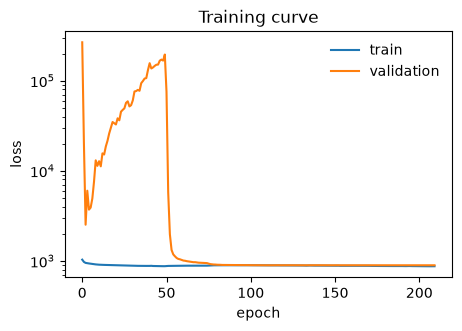

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="validation")
ax.set(xlabel="epoch", ylabel="loss", yscale="log", title="Training curve")
ax.legend(frameon=False)
plt.show()

`trainer.fit()` restores the weights from the best validation epoch. Validation loss is always computed with the full `beta` and `gamma`, so it is high during the first epochs, while the training loss is still annealing up from zero. That is why `best_epoch_warmup` is set to the end of the alignment ramp.

## 4. Embed held-out cells

Each encoder maps its modality into the same latent space. `latent="modality_mean"` returns the posterior mean from that modality alone, which is what you want for comparing modalities or for data where only one modality was measured.

In [8]:
z_rna = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
z_atac = encode_adata(model, test["atac"], modality="atac", device=device, latent="modality_mean")
z_rna.shape, z_atac.shape

((977, 30), (977, 30))

## 5. Check the integration

`stack_embeddings` puts both modalities' embeddings of the test cells into one AnnData (one row per cell per modality), ready for a joint UMAP. If integration worked, RNA and ATAC points interleave and cell types form shared clusters.

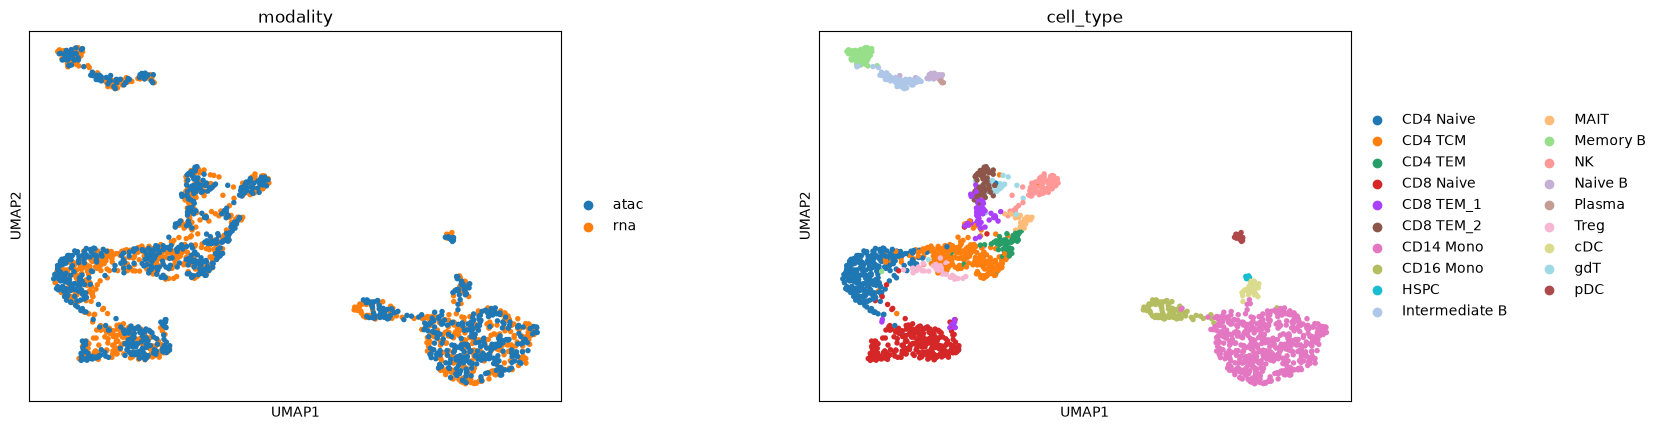

In [9]:
joint = stack_embeddings(model, [("test", "rna", test["rna"]), ("test", "atac", test["atac"])], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["modality", "cell_type"], wspace=0.35)

Because the cells are paired, we can measure alignment directly:

- **FOSCTTM**: for each cell, the fraction of other cells whose embedding is closer than its true partner in the other modality (0 is perfect, about 0.5 is random).
- **Recall@k**: how often the true partner is among the k nearest cross-modal neighbors.
- **Label transfer**: k-NN classification of ATAC cells from RNA labels (and the reverse).

In [10]:
labels = test["rna"].obs["cell_type"].astype(str).to_numpy()
metrics = evaluate_alignment(Z1=z_rna, Z2=z_atac, labels_source=labels, labels_target=labels,
                             recall_ks=(1, 10, 50))
pd.Series({
    "FOSCTTM (lower is better)": metrics["foscttm_mean"],
    "Recall@10": metrics["recall_at_k"]["10"]["mean"],
    "Label transfer accuracy (RNA to ATAC)": metrics["label_transfer_acc"],
    "Label transfer macro-F1, worse direction": metrics["worst_direction_macro_f1"],
}).round(3)

FOSCTTM (lower is better)                   0.022
Recall@10                                   0.529
Label transfer accuracy (RNA to ATAC)       0.920
Label transfer macro-F1, worse direction    0.748
dtype: float64

## 6. Predict RNA from ATAC

Decoders turn any latent point into any modality. Encoding ATAC and decoding RNA predicts expression (in the RNA model-input space: z-scored log-normalized values) for cells where you only have accessibility.

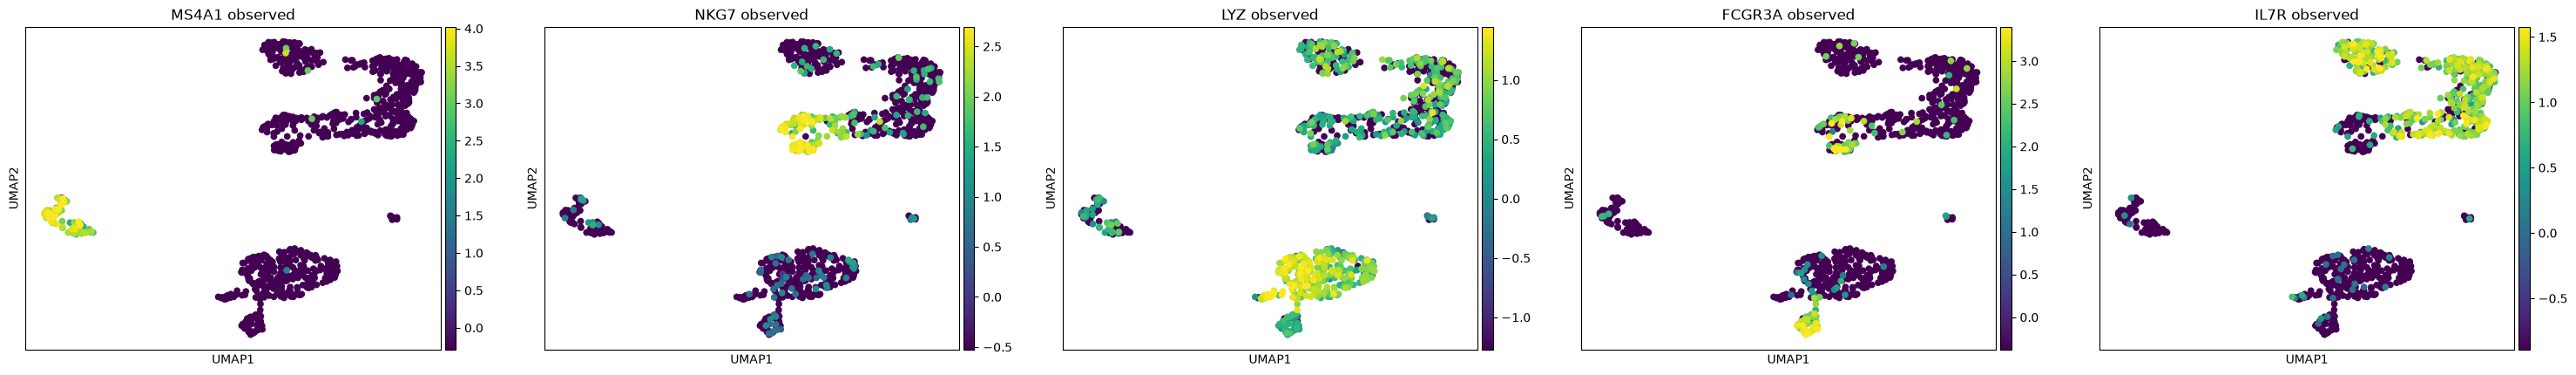

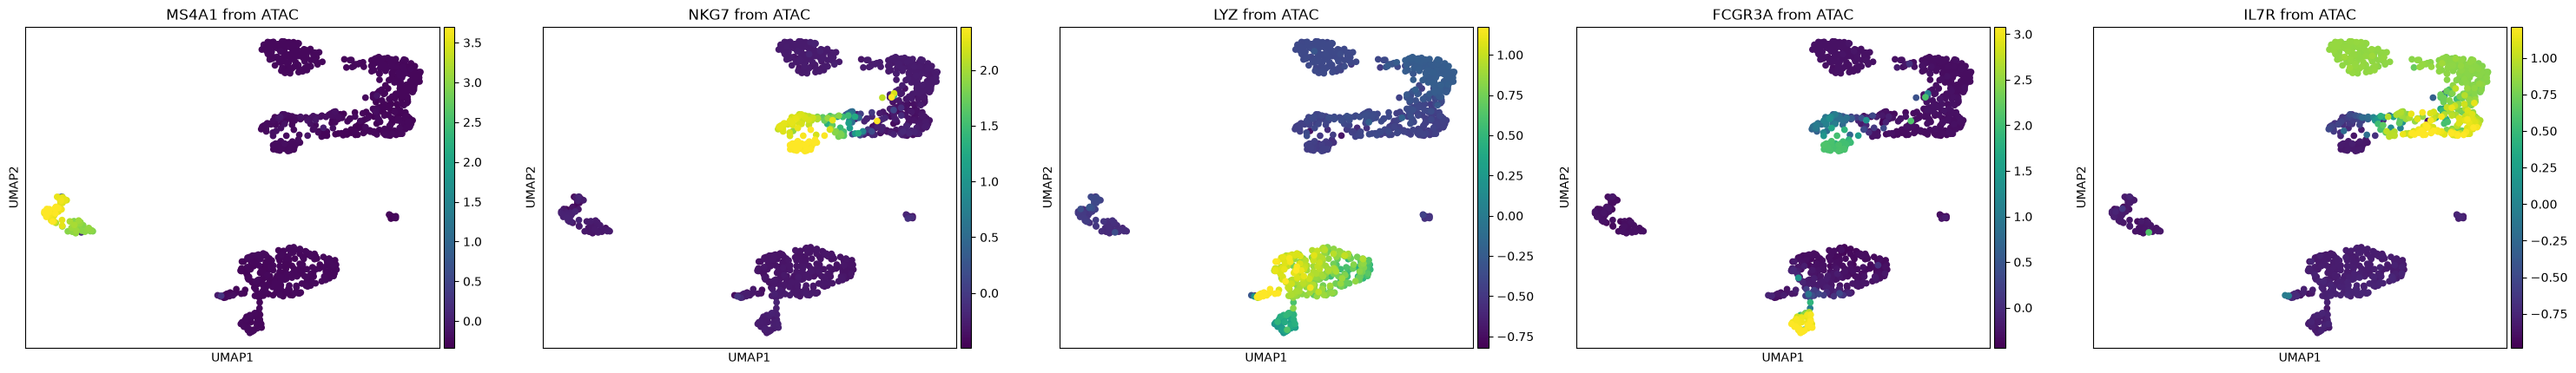

In [11]:
rna_test = test["rna"]
rna_test.layers["predicted_from_atac"] = cross_modal_predict(
    model, test["atac"], src_mod="atac", tgt_mod="rna", device=device)

markers = [g for g in ["MS4A1", "CD3D", "NKG7", "LYZ", "FCGR3A", "IL7R"] if g in rna_test.var_names]
rna_test.obsm["X_univi"] = z_rna
sc.pp.neighbors(rna_test, use_rep="X_univi")
sc.tl.umap(rna_test, random_state=0)
sc.pl.umap(rna_test, color=markers, ncols=len(markers), vmax="p99", cmap="viridis", title=[f"{g} observed" for g in markers])
sc.pl.umap(rna_test, color=markers, ncols=len(markers), layer="predicted_from_atac", vmax="p99", cmap="viridis", title=[f"{g} from ATAC" for g in markers])

Predictions are smoother than the measurements (they are decoder means, pulled toward what is typical for a cell's neighborhood), so compare the spatial patterns rather than the color scales. Per-gene correlation between observed and predicted values summarizes accuracy:

In [12]:
observed = np.asarray(rna_test.X)
predicted = rna_test.layers["predicted_from_atac"]
per_gene = pd.Series(pearson_corr_per_feature(observed, predicted), index=rna_test.var_names,
                     name="pearson_r").sort_values(ascending=False)
print(f"median per-gene Pearson r: {per_gene.median():.3f}")
per_gene.loc[markers].round(3)

median per-gene Pearson r: 0.271


genes
MS4A1     0.937
NKG7      0.801
LYZ       0.589
FCGR3A    0.741
IL7R      0.821
Name: pearson_r, dtype: float32

## 7. Save a reusable reference

A reference bundle stores the weights, the model configuration, and the fitted preprocessors, so new data can be embedded later without refitting anything.

In [13]:
save_reference("univi_multiome_reference", model,
               preprocessors={"rna": rna_prep, "atac": atac_prep},
               metadata={"dataset": "pbmc_multiome_10k", "best_epoch": trainer.best_epoch})

model2, preps, meta = load_reference("univi_multiome_reference", device=device)
new_cells = preps["rna"].transform(rna[splits["test"][:5]])
encode_adata(model2, new_cells, modality="rna", device=device, latent="modality_mean").shape

(5, 30)

`load_reference` unpickles the preprocessing file, so only load bundles you trust.

## Next steps

- [CITE-seq: RNA + protein](citeseq.ipynb): fused embeddings, protein imputation, modality weights
- [Map query data onto a reference](query_mapping.ipynb): RNA-only or ATAC-only cohorts, label transfer, imputing the missing modality
- [Cell-type heads and refinement](supervised_heads.ipynb): train classifiers on the latent space with partial labels
- [Imputation, denoising, generation](generation.ipynb): decode, sample, and probe the model
- [Custom modalities and likelihoods](custom_modalities.ipynb): three or more modalities, count and methylation likelihoods